<a href="https://colab.research.google.com/github/pari00720/AI-layoff-risk-prediction-using-ML-and-Streamlit/blob/main/ai_impact_layoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/ai-impact-jobs-layoff-risk-dataset.csv")

In [ ]:
df.head()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

In [ ]:
df.describe()

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000
mean,40.361500,7.265500,51.885500,47.786700,60.055000,2.460350,6.77395,37.22895,12.621400
std,11.526333,4.720606,24.437808,26.100482,22.267801,2.097486,6.08637,19.99512,13.552647
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.00000,4.00000,0.000000
25%,30.000000,4.000000,31.000000,27.000000,41.000000,1.000000,2.00000,21.00000,4.000000
50%,40.000000,7.000000,52.000000,48.000000,62.000000,2.000000,5.00000,35.00000,8.000000
75%,50.000000,11.000000,73.000000,69.000000,79.000000,4.000000,10.00000,51.00000,18.000000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.00000,93.00000,79.000000


In [ ]:
df['Education_Level'].unique()

array(["Master's", "Bachelor's", 'High School', 'PhD'], dtype=object)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
oe = OrdinalEncoder(categories=["Master's", "Bachelor's", 'High School', 'PhD'],dtype=object)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Define the order for Education_Level
education_order = ['High School', "Bachelor's", "Master's", 'PhD']

# Apply OrdinalEncoder to 'Education_Level'
oe_education = OrdinalEncoder(categories=[education_order])
df['Education_Level_Encoded'] = oe_education.fit_transform(df[['Education_Level']])

# Display the mapping and the first few rows with the new column
print("Education_Level Mapping:", dict(zip(education_order, oe_education.categories_[0])))
display(df[['Education_Level', 'Education_Level_Encoded']].head())

Education_Level Mapping: {'High School': 'High School', "Bachelor's": "Bachelor's", "Master's": "Master's", 'PhD': 'PhD'}


,Education_Level,Education_Level_Encoded
0,Master's,2.0
1,Master's,2.0
2,Bachelor's,1.0
3,Bachelor's,1.0
4,High School,0.0


ordinal encoding

*  sbse pehle import ordinalencoding from sklearn
*  then we need to define the order of items we want , in a list
* then create instance of ordinalencoder class , instance ka name - oe_education, then in the ()instance ,we will define categories order to to defined order list   
* then we will make new column education level encoded , then fit transform method me likhna h education level , it will learn mapping and make new column education level encoded
* fr print kr dete h in a zip , zip prints mapping that encoder learned in a dict of key value pairs   
* then display  







In [ ]:

job_level_order = ['Entry', 'Mid', 'Senior']


oe_job_level = OrdinalEncoder(categories=[job_level_order])
df['Job_Level_Encoded'] = oe_job_level.fit_transform(df[['Job_Level']])


print("Job_Level Mapping:", dict(zip(job_level_order, oe_job_level.categories_[0])))
display(df[['Job_Level', 'Job_Level_Encoded']].head())

Job_Level Mapping: {'Entry': 'Entry', 'Mid': 'Mid', 'Senior': 'Senior'}


,Job_Level,Job_Level_Encoded
0,Entry,0.0
1,Entry,0.0
2,Senior,2.0
3,Entry,0.0
4,Entry,0.0


In [ ]:

ai_adoption_order = ['Low', 'Medium', 'High']


oe_ai_adoption = OrdinalEncoder(categories=[ai_adoption_order])
df['AI_Adoption_Level_Encoded'] = oe_ai_adoption.fit_transform(df[['AI_Adoption_Level']])


print("AI_Adoption_Level Mapping:", dict(zip(ai_adoption_order, oe_ai_adoption.categories_[0])))
display(df[['AI_Adoption_Level', 'AI_Adoption_Level_Encoded']].head())

AI_Adoption_Level Mapping: {'Low': 'Low', 'Medium': 'Medium', 'High': 'High'}


,AI_Adoption_Level,AI_Adoption_Level_Encoded
0,Medium,1.0
1,Low,0.0
2,Low,0.0
3,Medium,1.0
4,Medium,1.0


### Encoding the Target Variable `Layoff_Risk`

In [ ]:

layoff_risk_order = ['Low', 'Medium', 'High']


oe_layoff_risk = OrdinalEncoder(categories=[layoff_risk_order])
df['Layoff_Risk_Encoded'] = oe_layoff_risk.fit_transform(df[['Layoff_Risk']])


print("Layoff_Risk Mapping:", dict(zip(layoff_risk_order, oe_layoff_risk.categories_[0])))
display(df[['Layoff_Risk', 'Layoff_Risk_Encoded']].head())

Layoff_Risk Mapping: {'Low': 'Low', 'Medium': 'Medium', 'High': 'High'}


,Layoff_Risk,Layoff_Risk_Encoded
0,High,2.0
1,Low,0.0
2,Low,0.0
3,High,2.0
4,Medium,1.0


### One-Hot Encoding for Nominal Categorical Features

In [ ]:
from sklearn.preprocessing import OneHotEncoder


nominal_features = ['Industry', 'Job_Role', 'Company_Size']


ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)


ohe_transformed = ohe.fit_transform(df[nominal_features])


ohe_df = pd.DataFrame(ohe_transformed, columns=ohe.get_feature_names_out(nominal_features))


df = pd.concat([df.drop(columns=nominal_features), ohe_df], axis=1)

display(df.head())

,Age,Education_Level,Years_of_Experience,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,...,Job_Role_Sales Associate,Job_Role_Software Engineer,Job_Role_Store Manager,Job_Role_Supply Chain Analyst,Job_Role_Support Specialist,Job_Role_Teacher,Job_Role_Warehouse Manager,Company_Size_Large,Company_Size_Medium,Company_Size_Small
0,59,Master's,6,Entry,84,21,94,Medium,5,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,44,Master's,14,Entry,30,84,68,Low,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,36,Bachelor's,7,Senior,12,86,71,Low,0,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,27,Bachelor's,6,Entry,90,18,21,Medium,3,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,49,High School,12,Entry,49,52,72,Medium,5,13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Feature Scaling for Numerical Features

In [ ]:
from sklearn.preprocessing import StandardScaler


numerical_features = [
    'Age', 'Years_of_Experience', 'Routine_Task_Percentage',
    'Creativity_Requirement', 'Human_Interaction_Level', 'Number_of_AI_Tools_Used',
    'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours'
]

scaler = StandardScaler()

df[numerical_features] = scaler.fit_transform(df[numerical_features])

display(df.head())

,Age,Education_Level,Years_of_Experience,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,...,Job_Role_Sales Associate,Job_Role_Software Engineer,Job_Role_Store Manager,Job_Role_Supply Chain Analyst,Job_Role_Support Specialist,Job_Role_Teacher,Job_Role_Warehouse Manager,Company_Size_Large,Company_Size_Medium,Company_Size_Small
0,1.617077,Master's,-0.268087,Entry,1.314165,-1.026317,1.524436,Medium,1.210837,0.037141,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.315676,Master's,1.426653,Entry,-0.895581,1.387492,0.356802,Low,-0.219483,-0.784387,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.378404,Bachelor's,-0.056244,Senior,-1.632163,1.464121,0.491529,Low,-1.173029,-0.948693,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.159244,Bachelor's,-0.268087,Entry,1.559692,-1.141260,-1.753922,Medium,0.257291,0.530058,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.749476,High School,1.002968,Entry,-0.118078,0.161430,0.536438,Medium,1.210837,1.022975,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split


X = df.drop(columns=['Layoff_Risk', 'Layoff_Risk_Encoded', 'Education_Level', 'Job_Level', 'AI_Adoption_Level'])
y = df['Layoff_Risk_Encoded']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16000, 47)
X_test shape: (4000, 47)
y_train shape: (16000,)
y_test shape: (4000,)


In [ ]:

output_filename = 'preprocessed_layoff_data.csv'
df.to_csv(output_filename, index=False)

print(f"Preprocessed data saved to '{output_filename}'")

Preprocessed data saved to 'preprocessed_layoff_data.csv'


You can now download this file to your local system using the following code:

In [ ]:
from google.colab import files

files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8862


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91      1320
         1.0       0.82      0.83      0.83      1320
         2.0       0.92      0.92      0.92      1360

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1200  120    0]
 [ 112 1099  109]
 [   0  114 1246]]


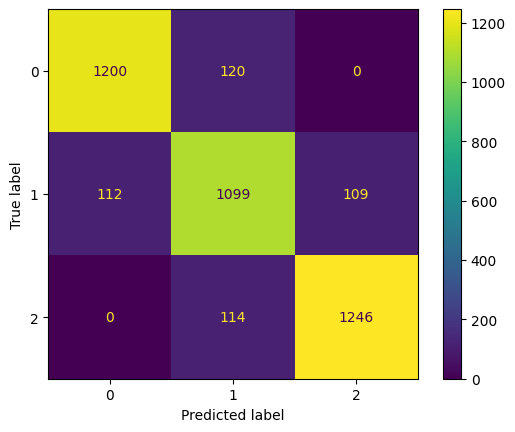

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

In [ ]:
import pickle

pickle.dump(
    rf,
    open("layoff_risk_model.pkl","wb")
)

In [ ]:
import pickle
import pandas as pd

with open("layoff_risk_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

print("Random Forest model loaded successfully.")


layoff_risk_mapping = {0.0: 'Low', 1.0: 'Medium', 2.0: 'High'}


Random Forest model loaded successfully.


In [ ]:
def preprocess_new_input(input_data):

    input_df = pd.DataFrame([input_data])


    input_df['Education_Level_Encoded'] = oe_education.transform(input_df[['Education_Level']])
    input_df['Job_Level_Encoded'] = oe_job_level.transform(input_df[['Job_Level']])
    input_df['AI_Adoption_Level_Encoded'] = oe_ai_adoption.transform(input_df[['AI_Adoption_Level']])

    nominal_features = ['Industry', 'Job_Role', 'Company_Size']
    ohe_transformed_input = ohe.transform(input_df[nominal_features])
    ohe_input_df = pd.DataFrame(ohe_transformed_input, columns=ohe.get_feature_names_out(nominal_features), index=input_df.index)


    processed_df = pd.concat([
        input_df.drop(columns=['Education_Level', 'Job_Level', 'AI_Adoption_Level'] + nominal_features),
        ohe_input_df
    ], axis=1)


    processed_df[numerical_features] = scaler.transform(processed_df[numerical_features])


    final_input = processed_df.reindex(columns=X_train.columns, fill_value=0)

    return final_input

print("Preprocessing function defined.")


Preprocessing function defined.


In [ ]:
user_input = {}


user_input['Age'] = int(input("Enter Age (e.g., 35): "))
user_input['Years_of_Experience'] = int(input("Enter Years of Experience (e.g., 10): "))
user_input['Routine_Task_Percentage'] = int(input("Enter Routine Task Percentage (0-100, e.g., 60): "))
user_input['Creativity_Requirement'] = int(input("Enter Creativity Requirement (0-100, e.g., 70): "))
user_input['Human_Interaction_Level'] = int(input("Enter Human Interaction Level (0-100, e.g., 50): "))
user_input['Number_of_AI_Tools_Used'] = int(input("Enter Number of AI Tools Used (e.g., 4): "))
user_input['AI_Usage_Hours_Per_Week'] = int(input("Enter AI Usage Hours Per Week (e.g., 15): "))
user_input['Tasks_Automated_Percentage'] = int(input("Enter Tasks Automated Percentage (0-100, e.g., 30): "))
user_input['AI_Training_Hours'] = int(input("Enter AI Training Hours (e.g., 20): "))


user_input['Education_Level'] = input("Enter Education Level (High School, Bachelor's, Master's, PhD): ").capitalize()
user_input['Job_Level'] = input("Enter Job Level (Entry, Mid, Senior): ").capitalize()
user_input['AI_Adoption_Level'] = input("Enter AI Adoption Level (Low, Medium, High): ").capitalize()
user_input['Industry'] = input("Enter Industry (e.g., Technology, Finance, Healthcare, Retail, Manufacturing, Education): ").capitalize()
user_input['Job_Role'] = input("Enter Job Role (e.g., Data Scientist, Software Engineer, Accountant, HR Manager, Marketing Specialist): ").capitalize()
user_input['Company_Size'] = input("Enter Company Size (Small, Medium, Large): ")

print("\nUser Input Received:")
for key, value in user_input.it2ems():
    print(f"  {key}: {value}")

Enter Age (e.g., 35): 34
Enter Years of Experience (e.g., 10): 32
Enter Routine Task Percentage (0-100, e.g., 60): 23
Enter Creativity Requirement (0-100, e.g., 70): 23
Enter Human Interaction Level (0-100, e.g., 50): 22
Enter Number of AI Tools Used (e.g., 4): 32
Enter AI Usage Hours Per Week (e.g., 15): 33
Enter Tasks Automated Percentage (0-100, e.g., 30): 22
Enter AI Training Hours (e.g., 20): 21
Enter Education Level (High School, Bachelor's, Master's, PhD): phD
Enter Job Level (Entry, Mid, Senior): senior
Enter AI Adoption Level (Low, Medium, High): high
Enter Industry (e.g., Technology, Finance, Healthcare, Retail, Manufacturing, Education): education
Enter Job Role (e.g., Data Scientist, Software Engineer, Accountant, HR Manager, Marketing Specialist): accountant
Enter Company Size (Small, Medium, Large): large

User Input Received:
  Age: 34
  Years_of_Experience: 32
  Routine_Task_Percentage: 23
  Creativity_Requirement: 23
  Human_Interaction_Level: 22
  Number_of_AI_Tools_U

In [ ]:
if user_input.get('Education_Level') == 'Phd':
    user_input['Education_Level'] = 'PhD'

preprocessed_user_input = preprocess_new_input(user_input)
prediction_encoded = rf_model.predict(preprocessed_user_input)[0]


predicted_layoff_risk = layoff_risk_mapping[prediction_encoded]

print(f"\nPredicted Layoff Risk: {predicted_layoff_risk}")


Predicted Layoff Risk: Low


Top 10 Most Important Features:


,Feature,Importance
2,Routine_Task_Percentage,0.182449
7,Tasks_Automated_Percentage,0.158506
3,Creativity_Requirement,0.135093
10,Job_Level_Encoded,0.093663
4,Human_Interaction_Level,0.045901
11,AI_Adoption_Level_Encoded,0.042859
6,AI_Usage_Hours_Per_Week,0.042657
8,AI_Training_Hours,0.040151
9,Education_Level_Encoded,0.037504
1,Years_of_Experience,0.035041


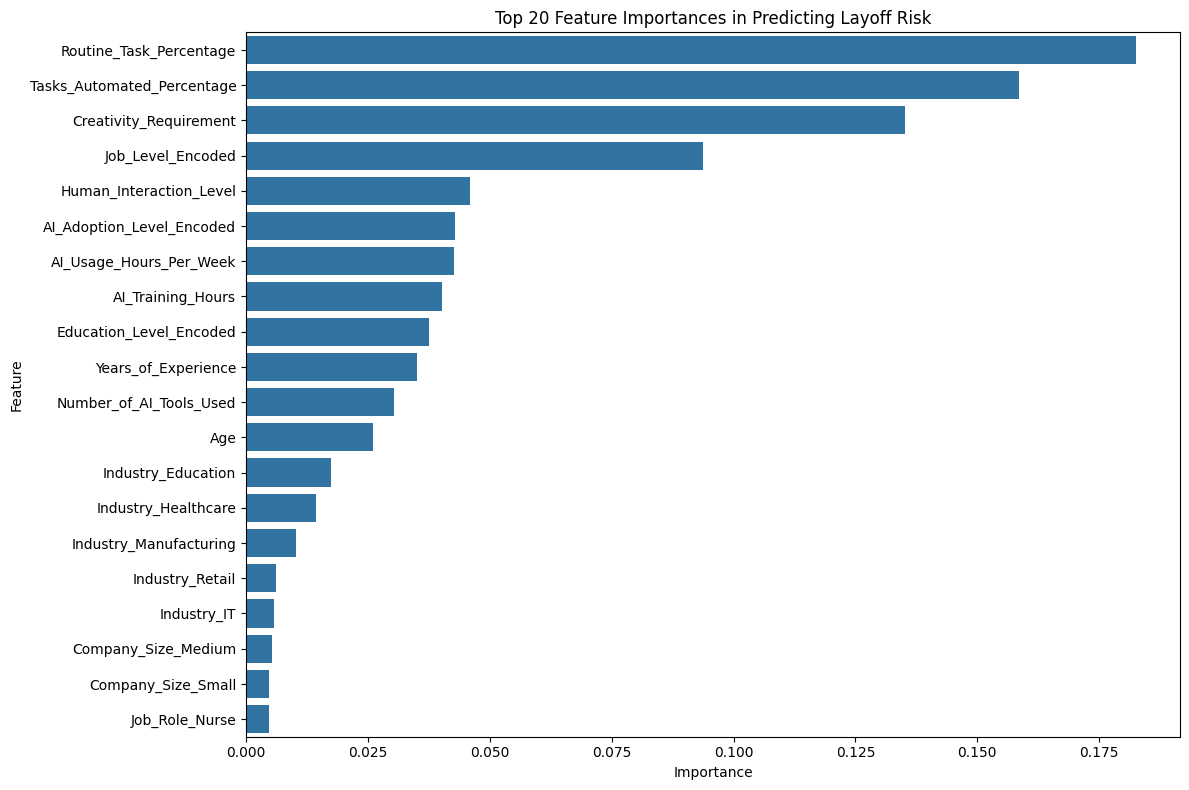

In [ ]:

importances = rf_model.feature_importances_


feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})


importance_df = importance_df.sort_values(by='Importance', ascending=False)


print("Top 10 Most Important Features:")
display(importance_df.head(10))
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances in Predicting Layoff Risk')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
import pickle

pickle.dump(rf, open("rf_model.pkl","wb"))

pickle.dump(scaler, open("scaler.pkl","wb"))

pickle.dump(ohe, open("ohe.pkl","wb"))

pickle.dump(oe_education, open("education_encoder.pkl","wb"))

pickle.dump(oe_job_level, open("job_encoder.pkl","wb"))

pickle.dump(oe_ai_adoption, open("ai_encoder.pkl","wb"))